In [1]:
from qualibrate import QualibrationNode
import numpy as np
import matplotlib.pyplot as plt

2026-02-27 16:07:37,704 - qm - INFO     - Starting session: 900865e6-8508-487b-8bbe-4efbca7d14ad


In [2]:
node  = QualibrationNode(name="quantum_memory_swapping")

2026-02-27 16:07:38,885 - qualibrate - INFO - Creating node quantum_memory_swapping


In [3]:
iSWAP_data = {
    'raw':{
        'axes':[],
        'axes_fit':[],
        'volume':[],
        'volume_fit':[],
        'negativity':[],
        'robustness':[],
    },
    'mle':{
        'axes':[],
        'axes_fit':[],
        'volume':[],
        'negativity':[],
        'negativity_fit':[],
        'robustness':[],
    },
    'sim':{
        'axes':[],
        'axes_fit':[],
        'volume':[],
        'volume_fit':[],
        'negativity':[],
        'negativity_fit':[],
        'robustness':[],
    }
}

In [4]:
from pathlib import Path
data_path = Path('/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/data/non_Markovian')


In [5]:
non_Markovian_experiment_index = [1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791,1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819]
interaction_time = np.arange(0,111,2)

# non_Markovian_experiment_index = np.arange(5938,5960,1)
# interaction_time = np.arange(0,161,8)

In [6]:
non_Markovian_ds ={
    f'interaction_time={interaction_time[i]}ns':node.load_from_id(non_Markovian_experiment_index[i],base_path=data_path).results['ds']
    for i in range(len(non_Markovian_experiment_index))
}
non_Markovian_key = non_Markovian_ds.keys()

In [7]:
from quam_libs.QI_utils import bloch_vector_to_density_matrix
from quam_libs.analyzer import QuantumMemoryAnalyze, EllipsoidFitParameters

fit_params = EllipsoidFitParameters(
    filter_method="convex",      # "none" | "convex" | "ransac"
    correct_rotation_orientation =True,
    find_best_order=False
)

In [8]:
non_Markovian_data = {}
non_Markovian_analyze={}
do_convex_hull = True
for i, key in enumerate(non_Markovian_key):
    ds = non_Markovian_ds[key]
    data_xyz = np.array([[ds.Bloch_vector_x.values[0][i], ds.Bloch_vector_y.values[0][i], ds.Bloch_vector_z.values[0][i]] for i in range(len(ds.n_points.values))])
    data_angle = np.array([[ds.theta.values[i], ds.phi.values[i]] for i in range(len(ds.n_points.values))])
    data_dm = np.array([bloch_vector_to_density_matrix(data_xyz[i]) for i in range(len(data_xyz))])

    noise_analyzer = QuantumMemoryAnalyze(data_xyz,data_angle,fit_params)
    corrected_dm = noise_analyzer.corrected_dm
    corrected_bloch = noise_analyzer.corrected_bloch
    ellipsoid_results = noise_analyzer.ellipsoid_fit_results()
    
    # Get choi state from the property
    choi_state = noise_analyzer.choi
    # Compute robustness using the static method
    robustness_value = QuantumMemoryAnalyze.memory_robustness(choi_state)
    
    non_Markovian_data[key] = {
        'data':{
            'original_xyz': data_xyz,
            'original_dm' :data_dm,
            'angle': data_angle,
            'corrected_xyz': corrected_bloch,
            'corrected_dm': corrected_dm
        },
        'ellipsoid':{
            'axes':ellipsoid_results['axes'],
            'center':ellipsoid_results['center'],
            'volume':ellipsoid_results['volume'],
            'param':ellipsoid_results['fit_param'],
            "rotation_matrix":ellipsoid_results['rotation_matrix'],
        },
        "quantum_information":{
            "choi":choi_state,
            "robustness":robustness_value
        }
    }
    non_Markovian_analyze[key] = noise_analyzer


## change the order

In [9]:
import itertools
from quam_libs.macros import ellipsoid_to_quadric

# Reload the module to get the updated staticmethod definition
import importlib
import quam_libs.analyzer
importlib.reload(quam_libs.analyzer)
from quam_libs.analyzer import QuantumMemoryAnalyze

np.set_printoptions(precision=3, suppress=True)

keys = non_Markovian_data.keys()
perm_robustness_dict = {}
for i in range(1):
    for key in keys:
        print(f"Results for {key}:")
        R = non_Markovian_data[key]['ellipsoid']['rotation_matrix']
        center = non_Markovian_data[key]['ellipsoid']['center']
        axes = non_Markovian_data[key]['ellipsoid']['axes']
        print(f"R for {key}:\n{R}")
        print(f"Center for {key}:\n{center}")
        print(f"Axes for {key}:\n{axes}")
        
        # Compute Choi state from ellipsoid parameters
        choi = QuantumMemoryAnalyze.choi_state(center, axes, R)
        correct_choi = QuantumMemoryAnalyze.correct_choi(choi)
        # Recompute robustness from the Choi state using static method
        robustness = QuantumMemoryAnalyze.memory_robustness(correct_choi)
        print(f"Quantum robustness for {key}: {robustness:.3f}")
        print('-'*75)

        perms = list(itertools.permutations([0,1,2]))
        perm_robustness_dict[key] = {}
        for perm in np.array(perms):
            # Properly permute rotation matrix columns to match axes permutation
            R_perm = non_Markovian_data[key]['ellipsoid']['rotation_matrix'][:, perm]
            axes_perm = non_Markovian_data[key]['ellipsoid']['axes'][perm]
            
            # Compute robustness for this permutation
            choi_perm = QuantumMemoryAnalyze.choi_state(center, axes_perm, R_perm)
            correct_choi_perm = QuantumMemoryAnalyze.correct_choi(choi_perm)
            robustness_perm = QuantumMemoryAnalyze.memory_robustness(correct_choi_perm)
            
            perm_robustness_dict[key][tuple(perm)] = robustness_perm
            print(f"Permutation {perm} robustness: {robustness_perm:.3f}")
        
        # Find permutation with maximum robustness
        max_perm = list(max(perm_robustness_dict[key], key=perm_robustness_dict[key].get))
        print(f"Best permutation {max_perm} with robustness {perm_robustness_dict[key][tuple(max_perm)]:.3f}")

        # Apply best permutation to rotation matrix columns
        R = R[:, max_perm]
        axes = axes[max_perm]
        if np.linalg.det(R) > 0:
            R[0,:]*=-1 
        print(f'after swap')
        print(f"R for {key}:\n{R} and det(R) = {np.linalg.det(R)}")
        print(f"Center for {key}:\n{center}")
        print(f"Axes for {key}:\n{axes}")
        choi = QuantumMemoryAnalyze.choi_state(center, axes, R)
        correct_choi = QuantumMemoryAnalyze.correct_choi(choi)
        robustness = QuantumMemoryAnalyze.memory_robustness(correct_choi)
        print(f"Robustness for {key}: {robustness:.3f}")
        print(f"Choi state for {key}:\n{correct_choi}")
        print('-'*100)
        non_Markovian_data[key]['ellipsoid']['rotation_matrix'] = R
        non_Markovian_data[key]['ellipsoid']['axes'] = axes
        non_Markovian_data[key]['ellipsoid']['center'] = center
        non_Markovian_data[key]['quantum_information']['robustness'] = robustness
        non_Markovian_data[key]['quantum_information']['choi'] = correct_choi

Results for interaction_time=0ns:
R for interaction_time=0ns:
[[ 0.365 -0.41   0.836]
 [-0.748 -0.664  0.   ]
 [-0.555  0.625  0.549]]
Center for interaction_time=0ns:
[0.024 0.024 0.03 ]
Axes for interaction_time=0ns:
[0.631 0.722 0.665]


/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(
/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
/Users/jackchao/Desktop/Proje

Choi state is invalid:
❌ Partial trace of the Choi state is not 1. Got trace = 0.022848352549732207
After 2 iterations, the Choi state is valid.
Quantum robustness for interaction_time=0ns: 0.263
---------------------------------------------------------------------------
Choi state is invalid:
❌ Partial trace of the Choi state is not 1. Got trace = 0.022848352549732207
After 2 iterations, the Choi state is valid.
Permutation [0 1 2] robustness: 0.263
Choi state is invalid:
❌ Partial trace of the Choi state is not 1. Got trace = 0.0228483525497322
After 2 iterations, the Choi state is valid.
Permutation [0 2 1] robustness: 0.000
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.189  0.351  0.394  0.445]
❌ Partial trace of the Choi state is not 1. Got trace = 0.02284835254973221
After 2 iterations, the Choi state is valid.
Permutation [1 0 2] robustness: 0.000
Choi state is invalid:
❌ Partial trace of the Choi state is not 1. Got trace = 0.02284835254973

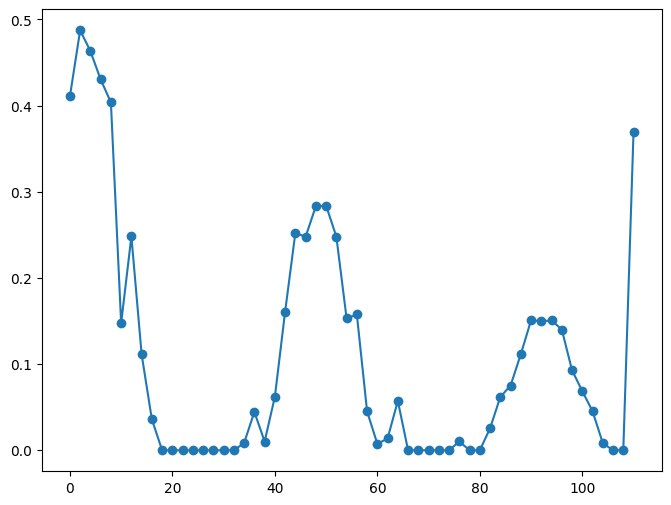

In [10]:
robustness_list = [non_Markovian_data[key]['quantum_information']['robustness'] for key in non_Markovian_key]
plt.figure(figsize=(8,6))
plt.plot(interaction_time, robustness_list, marker='o')